<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Toy_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit ipywidgets
!pip install pylatexenc

!pip install galois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d7ea9705822130c390e1be19ec2313171de1b6ca508d7cd19b780bb488aebc8b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 41.1 MB/s eta 0:00:00


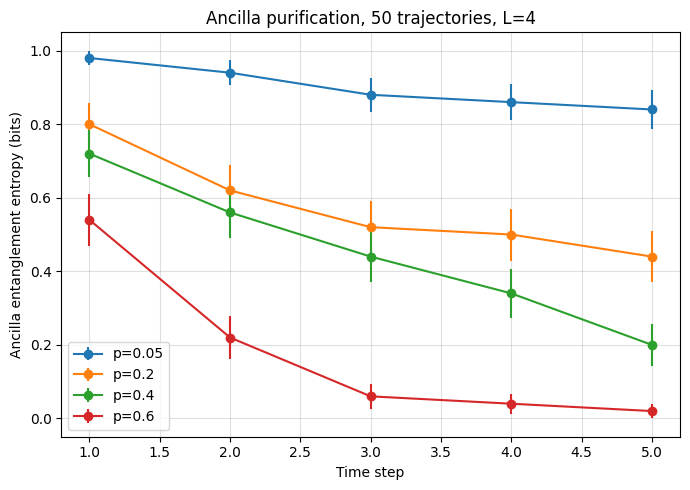

In [7]:
import numpy as np
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import StabilizerState, Clifford, random_clifford
import matplotlib.pyplot as plt

rng = np.random.default_rng()

def gf2_rank(matrix):
    """Rank of a binary matrix over GF(2) via Gaussian elimination."""
    m = (matrix.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    rank = 0
    for col in range(cols):
        pivot = None
        for r in range(rank, rows):
            if m[r, col]:
                pivot = r
                break
        if pivot is None:
            continue
        m[[rank, pivot]] = m[[pivot, rank]]
        for r in range(rows):
            if r != rank and m[r, col]:
                m[r] = (m[r] + m[rank]) % 2
        rank += 1
    return rank

def ancilla_entropy(state, ancilla_col=0):
    """S_A = rank_GF2(stabilizer restricted to A) - |A|, for a 1-qubit ancilla."""
    cliff = state.clifford
    x_col = cliff.stab_x[:, ancilla_col:ancilla_col+1].astype(np.uint8)
    z_col = cliff.stab_z[:, ancilla_col:ancilla_col+1].astype(np.uint8)
    M_A = np.concatenate([x_col, z_col], axis=1)
    return gf2_rank(M_A) - 1

def brickwork_layer(state, system_qubits, t, periodic=True):
    """One staggered even/odd brickwork layer of random 2-qubit Cliffords."""
    L = len(system_qubits)
    offset = t % 2
    j = offset
    while j + 1 < L:
        u2 = random_clifford(2)
        state = state.evolve(Clifford(u2), qargs=[system_qubits[j], system_qubits[j+1]])
        j += 2
    if periodic and offset == 1 and L % 2 == 0:
        u2 = random_clifford(2)
        state = state.evolve(Clifford(u2), qargs=[system_qubits[L-1], system_qubits[0]])
    return state

def measure_layer(state, system_qubits, p_measure):
    """Independently measure EACH system qubit with probability p_measure."""
    for q in system_qubits:
        if rng.random() < p_measure:
            _, state = state.measure([q])
    return state

def run_trajectory(size, T, p_measure, t_scramble=0, periodic=True):
    Ancilla = QuantumRegister(1, 'ancilla')
    System = QuantumRegister(size, 'system')
    qc = QuantumCircuit(Ancilla, System)
    system_qubits = list(range(1, size + 1))  # global indices; ancilla = 0

    if t_scramble > 0:
        # Phase 1: scramble the system ALONE, no ancilla coupling yet
        qc_sys = QuantumCircuit(size)
        state = StabilizerState(qc_sys)
        for t in range(t_scramble):
            state = brickwork_layer(state, list(range(size)), t, periodic=periodic)
        # rebuild as (ancilla + system), then couple
        full_qc = QuantumCircuit(Ancilla, System)
        state = StabilizerState(full_qc).evolve(Clifford(state.clifford.to_circuit()),
                                                  qargs=list(range(1, size + 1)))
        state = state.evolve(Clifford(QuantumCircuit(1).compose(QuantumCircuit(1))), qargs=[0])  # no-op, ancilla stays |0>
        qc2 = QuantumCircuit(1)
        qc2.h(0)
        state = state.evolve(Clifford(qc2), qargs=[0])
        cx = QuantumCircuit(2); cx.cx(0, 1)
        state = state.evolve(Clifford(cx), qargs=[0, size // 2 + 1])
    else:
        qc.h(Ancilla)
        qc.cx(Ancilla, System[size // 2])
        state = StabilizerState(qc)

    entropy_history = np.zeros(T)
    for t in range(T):
        state = brickwork_layer(state, system_qubits, t, periodic=periodic)
        state = measure_layer(state, system_qubits, p_measure)
        entropy_history[t] = ancilla_entropy(state, ancilla_col=0)
    return entropy_history

def run_averaged(size, T, p_measure, n_trials=200, t_scramble=0, periodic=True):
    all_S = np.zeros((n_trials, T))
    for k in range(n_trials):
        all_S[k] = run_trajectory(size, T, p_measure, t_scramble=t_scramble, periodic=periodic)
    return all_S.mean(axis=0), all_S.std(axis=0) / np.sqrt(n_trials)

# --- Run and plot ---
size = 4          # even size -> clean periodic brickwork, matches the paper's 2L convention
T = 5
n_trials = 50

plt.figure(figsize=(7, 5))
for p in [0.05, 0.2, 0.4, 0.6]:
    mean_S, sem_S = run_averaged(size, T, p, n_trials=n_trials)
    plt.errorbar(range(1, T + 1), mean_S, yerr=sem_S, marker='o', label=f"p={p}")

plt.xlabel("Time step")
plt.ylabel("Ancilla entanglement entropy (bits)")
plt.title(f"Ancilla purification, {n_trials} trajectories, L={size}")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()